In [93]:
# https://stackabuse.com/hierarchical-clustering-with-python-and-scikit-learn/
# https://blog.csdn.net/qq_42722197/article/details/122518847
# https://www.geeksforgeeks.org/python-flatten-nested-tuples/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

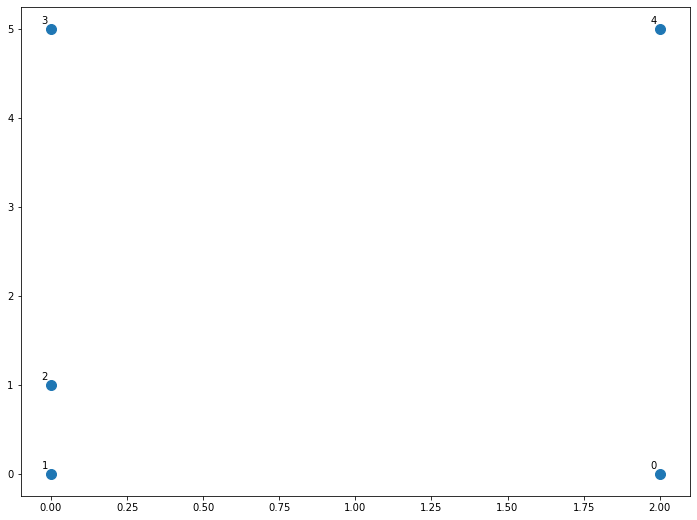

In [95]:
### draw the points

X = np.array([
    [2, 0], [0, 0], [0, 1], [0, 5], [2, 5]
])
x = X[:, 0]
y = X[:, 1]
plt.figure(figsize=(12, 9))
plt.scatter(x, y, s=100)

for label, x, y in zip(range(len(X)), x, y):
    plt.annotate(
        label,
        xy=(x, y), xytext=(-3, 3),
        textcoords='offset points', ha='right', va='bottom')

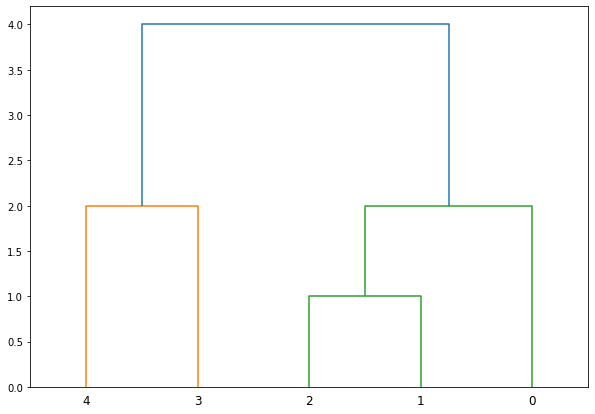

In [96]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

linked = linkage(X, 'single')

plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=range(len(X)),
            distance_sort='descending',
            show_leaf_counts=True)
plt.show()

# manually calcuate

In [97]:
import pandas as pd
import numpy as np

# calculate distence between two cords
def euclidean_distance(cord1, cord2):
    return np.sqrt( (cord1[0] - cord2[0]) ** 2 + (cord1[1] - cord2[1]) ** 2 )

# relative index and columns of nearest clusters
def closest_clusters(distances):
    distances[distances==0]=np.inf
    A = distances.values
    return A.argmin()//A.shape[1], A.argmin()%A.shape[1]

# combine nearst clusters
def combine_cluster(clusters, nearest_clusters):
    clusters.append((clusters[nearest_clusters[0]], clusters[nearest_clusters[1]]))
    for c in sorted(nearest_clusters, reverse=True):
        clusters.pop(c)
    return clusters

# flatten tuple
def flatten(test_tuple):
    if isinstance(test_tuple, tuple) and len(test_tuple) == 1 and not isinstance(test_tuple[0], tuple):
        return test_tuple
  
    res = []
    for sub in test_tuple:
        res += flatten(sub)
    return tuple(res)

# calculate distence between new clusters
def cluster_distance(cluster1, cluster2):
    min = np.inf
    for p1 in flatten(cluster1):
        for p2 in flatten(cluster2):
            cord1, cord2 = X[r[0]], X[c[0]]
            distance = euclidean_distance(cord1, cord2)
            if distance < min:
                min = distance
    return min

In [98]:
# set each point as a cluster
X = np.array([
    [2, 0], [0, 0], [0, 1], [0, 5], [2, 5]
])
clusters = [(x,) for x in range(len(X))]
print("clusters:\n ", clusters)

distances = pd.DataFrame(index=clusters, columns=clusters)
for r in clusters:
    for c  in clusters:
        cord1, cord2 = X[r[0]], X[c[0]]
        distances.at[r, c] = euclidean_distance(cord1, cord2).round(2)
print("\ndistances between each cluster:")
distances

clusters:
  [(0,), (1,), (2,), (3,), (4,)]

distances between each cluster:


,"(0,)","(1,)","(2,)","(3,)","(4,)"
"(0,)",0.0,2.0,2.24,5.39,5.0
"(1,)",2.0,0.0,1.0,5.0,5.39
"(2,)",2.24,1.0,0.0,4.0,4.47
"(3,)",5.39,5.0,4.0,0.0,2.0
"(4,)",5.0,5.39,4.47,2.0,0.0


In [99]:
# find closest clusters
# (1, 2) means row1&column2
nearest_clusters = closest_clusters(distances)
nearest_clusters

(1, 2)

In [100]:
# combine the closest

combine_cluster(clusters, nearest_clusters)
clusters

[(0,), (3,), (4,), ((1,), (2,))]

In [101]:
# calculate distence between new clusters

distances = pd.DataFrame(index=clusters, columns=clusters)
for r in clusters:
    for c  in clusters:
        distances.at[r, c] = cluster_distance(r, c).round(2)
print("\ndistances between each cluster:")
distances


distances between each cluster:


,"(0,)","(3,)","(4,)","((1,), (2,))"
"(0,)",0.0,5.39,5.0,2.0
"(3,)",5.39,0.0,2.0,5.0
"(4,)",5.0,2.0,0.0,5.39
"((1,), (2,))",2.0,5.0,5.39,0.0


In [102]:
# find closest clusters
nearest_clusters = closest_clusters(distances)
nearest_clusters

(0, 3)

In [103]:
# combine the closest
combine_cluster(clusters, nearest_clusters)
clusters

[(3,), (4,), ((0,), ((1,), (2,)))]

In [104]:
# calculate distence between new clusters
distances = pd.DataFrame(index=clusters, columns=clusters)
for r in clusters:
    for c  in clusters:
        distances.at[r, c] = cluster_distance(r, c).round(2)
print("\ndistances between each cluster:")
distances


distances between each cluster:


,"(3,)","(4,)","((0,), ((1,), (2,)))"
"(3,)",0.0,2.0,5.39
"(4,)",2.0,0.0,5.0
"((0,), ((1,), (2,)))",5.39,5.0,0.0


In [105]:
# find closest clusters
nearest_clusters = closest_clusters(distances)
nearest_clusters

(0, 1)

In [106]:
# combine the closest
combine_cluster(clusters, nearest_clusters)
clusters

[((0,), ((1,), (2,))), ((3,), (4,))]

In [107]:
# calculate distence between new clusters
distances = pd.DataFrame(index=clusters, columns=clusters)
for r in clusters:
    for c  in clusters:
        distances.at[r, c] = cluster_distance(r, c).round(2)
print("\ndistances between each cluster:")
distances


distances between each cluster:


,"((0,), ((1,), (2,)))","((3,), (4,))"
"((0,), ((1,), (2,)))",0.0,5.39
"((3,), (4,))",5.39,0.0
